# Peliculas Rotten-Tomatoes
 
En nuestro proyecto vamos a utilizar el rotten_tomatoes_movies.csv
 
Objetivos:
1. Cargar datos.
2. Limpieza y preparación de datos.
3. Análisis exploratorio.
 
    3.1 Estadísticas globales
 
    3.2 Análisis por género
 
    3.3 Análisis por estudio o director
 
    3.4 Análisis temporal
   
    3.5 Análisis de retraso a streaming (si aplica)
4. Uso de NumPy para análisis auxiliar.
5. Preguntas.
6. Conclusiones.

## 1. Carga de datos

In [24]:
# Instala pandas en el kernel actual (usa %pip para asegurar instalación en este entorno)
%pip install -q pandas
%pip install -q matplotlib
 
import matplotlib.pyplot as plt

import pandas as pd

# Aquí vamos a utilizar nuestro csv que es el rotten_tomatoes_movies.csv
df = pd.read_csv("rotten_tomatoes_movies.csv")

# Mostramos las primeras filas de nuestro csv
display(df.head())

# Como nuestro csv mayoritariamente tiene texto utilizaremos el .info en vez del .describe que es para numéricas
df.info()

# Estadísticas básicas (incluyendo texto)
display(df.describe(include='all'))

#CONVERSION DE TIPOS
print("Tipos ANTES:")
print(df.dtypes)

# Conversión in_theaters_date y on_streaming_date a datetime
df['in_theaters_date'] = pd.to_datetime(df['in_theaters_date'], errors='coerce', dayfirst=True)
df['on_streaming_date'] = pd.to_datetime(df['on_streaming_date'], errors='coerce', dayfirst=True)

# Conversión in_theaters_date y on_streaming_date a datetime
df['runtime_in_minutes'] = pd.to_numeric(df['runtime_in_minutes'], errors='coerce')
df['tomatometer_rating'] = pd.to_numeric(df['tomatometer_rating'], errors='coerce')
df['audience_rating'] = pd.to_numeric(df['audience_rating'], errors='coerce')
df['tomatometer_count'] = pd.to_numeric(df['tomatometer_count'], errors='coerce')
df['audience_count'] = pd.to_numeric(df['audience_count'], errors='coerce')



print("\nTipos DESPUÉS:")
print(df.dtypes)

display(df.head())


Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.2 -> 25.3
[notice] To update, run: python.exe -m pip install --upgrade pip

[notice] A new release of pip is available: 25.2 -> 25.3
[notice] To update, run: python.exe -m pip install --upgrade pip


Note: you may need to restart the kernel to use updated packages.


,movie_title,movie_info,critics_consensus,rating,genre,directors,writers,cast,in_theaters_date,on_streaming_date,runtime_in_minutes,studio_name,tomatometer_status,tomatometer_rating,tomatometer_count,audience_rating,audience_count,columna_vacia
0,Percy Jackson & the Olympians: The Lightning T...,A teenager discovers he's the descendant of a ...,Though it may seem like just another Harry Pot...,PG,"Action & Adventure, Comedy, Drama, Science Fic...",Chris Columbus,Craig Titley,"Logan Lerman, Brandon T. Jackson, Alexandra Da...",2010-02-12,2010-06-29,83.0,20th Century Fox,Rotten,49,144,53.0,254287.0,NaN
1,Percy Jackson & the Olympians: The Lightning T...,A teenager discovers he's the descendant of a ...,Though it may seem like just another Harry Pot...,PG,"Action & Adventure, Comedy, Drama, Science Fic...",Chris Columbus,Craig Titley,"Logan Lerman, Brandon T. Jackson, Alexandra Da...",2010-02-12,2010-06-29,83.0,20th Century Fox,Rotten,49,144,53.0,254287.0,NaN
2,Please Give,Kate has a lot on her mind. There's the ethics...,Nicole Holofcener's newest might seem slight i...,R,Comedy,Nicole Holofcener,Nicole Holofcener,"Catherine Keener, Amanda Peet, Oliver Platt, R...",2010-04-30,2010-10-19,90.0,Sony Pictures Classics,Certified Fresh,86,140,64.0,11567.0,NaN
3,10,Blake Edwards' 10 stars Dudley Moore as George...,NaN,R,"Comedy, Romance",Blake Edwards,Blake Edwards,"Dudley Moore, Bo Derek, Julie Andrews, Robert ...",1979-10-05,1997-08-27,118.0,Waner Bros.,Fresh,68,22,53.0,14670.0,NaN
4,12 Angry Men (Twelve Angry Men),"A Puerto Rican youth is on trial for murder, a...",Sidney Lumet's feature debut is a superbly wri...,NR,"Classics, Drama",Sidney Lumet,Reginald Rose,"Martin Balsam, John Fiedler, Lee J. Cobb, E.G....",1957-04-13,2001-03-06,95.0,Criterion Collection,Certified Fresh,100,51,97.0,105000.0,NaN


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 16639 entries, 0 to 16638
Data columns (total 18 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   movie_title         16639 non-null  object 
 1   movie_info          16615 non-null  object 
 2   critics_consensus   8310 non-null   object 
 3   rating              16639 non-null  object 
 4   genre               16622 non-null  object 
 5   directors           16525 non-null  object 
 6   writers             15290 non-null  object 
 7   cast                16355 non-null  object 
 8   in_theaters_date    15824 non-null  object 
 9   on_streaming_date   16637 non-null  object 
 10  runtime_in_minutes  16484 non-null  float64
 11  studio_name         16223 non-null  object 
 12  tomatometer_status  16639 non-null  object 
 13  tomatometer_rating  16639 non-null  int64  
 14  tomatometer_count   16639 non-null  int64  
 15  audience_rating     16387 non-null  float64
 16  audi

,movie_title,movie_info,critics_consensus,rating,genre,directors,writers,cast,in_theaters_date,on_streaming_date,runtime_in_minutes,studio_name,tomatometer_status,tomatometer_rating,tomatometer_count,audience_rating,audience_count,columna_vacia
count,16639,16615,8310,16639,16622,16525,15290,16355,15824,16637,16484.000000,16223,16639,16639.000000,16639.000000,16387.000000,1.638700e+04,0.0
unique,16106,16613,8307,8,1080,8314,12121,16326,5586,2260,NaN,2886,3,NaN,NaN,NaN,NaN,NaN
top,Home,A teenager discovers he's the descendant of a ...,High Life is as visually arresting as it is ch...,R,Drama,Alfred Hitchcock,Woody Allen,Werner Herzog,2002-01-01,2004-06-01,NaN,Paramount Pictures,Rotten,NaN,NaN,NaN,NaN,NaN
freq,5,2,2,6136,1727,36,33,4,28,71,NaN,497,7234,NaN,NaN,NaN,NaN,NaN
mean,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,102.390318,NaN,NaN,60.465833,56.612357,60.470373,1.524859e+05,NaN
std,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,25.027707,NaN,NaN,28.586509,66.385262,20.461826,1.817681e+06,NaN
min,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.000000,NaN,NaN,0.000000,5.000000,0.000000,5.000000e+00,NaN
25%,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,90.000000,NaN,NaN,38.000000,12.000000,45.000000,8.645000e+02,NaN
50%,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,99.000000,NaN,NaN,66.000000,28.000000,62.000000,4.877000e+03,NaN
75%,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,111.000000,NaN,NaN,86.000000,76.000000,77.000000,2.876650e+04,NaN


Tipos ANTES:
movie_title            object
movie_info             object
critics_consensus      object
rating                 object
genre                  object
directors              object
writers                object
cast                   object
in_theaters_date       object
on_streaming_date      object
runtime_in_minutes    float64
studio_name            object
tomatometer_status     object
tomatometer_rating      int64
tomatometer_count       int64
audience_rating       float64
audience_count        float64
columna_vacia         float64
dtype: object

Tipos DESPUÉS:
movie_title                   object
movie_info                    object
critics_consensus             object
rating                        object
genre                         object
directors                     object
writers                       object
cast                          object
in_theaters_date      datetime64[ns]
on_streaming_date     datetime64[ns]
runtime_in_minutes           float64
studio_nam

C:\Users\Mario\AppData\Local\Temp\ipykernel_21104\1017798719.py:27: UserWarning: Parsing dates in %Y-%m-%d format when dayfirst=True was specified. Pass `dayfirst=False` or specify a format to silence this warning.
  df['on_streaming_date'] = pd.to_datetime(df['on_streaming_date'], errors='coerce', dayfirst=True)


,movie_title,movie_info,critics_consensus,rating,genre,directors,writers,cast,in_theaters_date,on_streaming_date,runtime_in_minutes,studio_name,tomatometer_status,tomatometer_rating,tomatometer_count,audience_rating,audience_count,columna_vacia
0,Percy Jackson & the Olympians: The Lightning T...,A teenager discovers he's the descendant of a ...,Though it may seem like just another Harry Pot...,PG,"Action & Adventure, Comedy, Drama, Science Fic...",Chris Columbus,Craig Titley,"Logan Lerman, Brandon T. Jackson, Alexandra Da...",2010-12-02,2010-06-29,83.0,20th Century Fox,Rotten,49,144,53.0,254287.0,NaN
1,Percy Jackson & the Olympians: The Lightning T...,A teenager discovers he's the descendant of a ...,Though it may seem like just another Harry Pot...,PG,"Action & Adventure, Comedy, Drama, Science Fic...",Chris Columbus,Craig Titley,"Logan Lerman, Brandon T. Jackson, Alexandra Da...",2010-12-02,2010-06-29,83.0,20th Century Fox,Rotten,49,144,53.0,254287.0,NaN
2,Please Give,Kate has a lot on her mind. There's the ethics...,Nicole Holofcener's newest might seem slight i...,R,Comedy,Nicole Holofcener,Nicole Holofcener,"Catherine Keener, Amanda Peet, Oliver Platt, R...",NaT,2010-10-19,90.0,Sony Pictures Classics,Certified Fresh,86,140,64.0,11567.0,NaN
3,10,Blake Edwards' 10 stars Dudley Moore as George...,NaN,R,"Comedy, Romance",Blake Edwards,Blake Edwards,"Dudley Moore, Bo Derek, Julie Andrews, Robert ...",1979-05-10,1997-08-27,118.0,Waner Bros.,Fresh,68,22,53.0,14670.0,NaN
4,12 Angry Men (Twelve Angry Men),"A Puerto Rican youth is on trial for murder, a...",Sidney Lumet's feature debut is a superbly wri...,NR,"Classics, Drama",Sidney Lumet,Reginald Rose,"Martin Balsam, John Fiedler, Lee J. Cobb, E.G....",NaT,2001-03-06,95.0,Criterion Collection,Certified Fresh,100,51,97.0,105000.0,NaN


## 2. Limpieza y preparación de datos

In [20]:
# Detectar filas duplicadas completas
duplicados = df[df.duplicated()]
print("Filas duplicadas detectadas:")
display(duplicados)

# Eliminar duplicados
df.drop_duplicates(inplace=True)

print("Tamaño tras eliminar duplicados:", df.shape)

# Conteo de valores nulos por columna
print("Valores nulos por columna:")
print(df.isna().sum())

# Eliminamos columnas que estén completamente vacías
print("Columnas actuales del DataFrame:")
print(df.columns.tolist())
df.dropna(axis=1, how='all', inplace=True)

print("Columnas actuales del DataFrame:")
print(df.columns.tolist())

# Normalizar el campo genre:
# - quitar espacios en blanco
# - poner la primera letra en mayúscula de cada palabra
# - eliminar espacios internos (Acción  -> Acción, 'Ciencia Ficcion' -> 'CienciaFiccion')
df['genre'] = (
    df['genre']
      .astype(str)
      .str.strip()
      .str.title()
      .str.replace(' ', '', regex=False)
)
 
display(df[['genre']].head(10))
 
# Buscar todas las filas que contienen "Horror"
horror_rows = df[df['genre'].str.contains('Horror', case=False, na=False)]
print("Filas con Horror:")
display(horror_rows)

# Aquí vamos a hacer distintas columnas derivadas que nos serviran para hacer distintas busquedas

    # Empezaremos mostrando la diferencia de días entre el estreno en cines y el estreno en teatros.
df['days_to_streaming'] = df['on_streaming_date'] - df['in_theaters_date'] 
print("[Días de diferencia en el estreno")
display(df[['movie_title', 'days_to_streaming']])

#Ahora vamos a contar el total de votos, sumando los votos del tomatometer y los de la audiencia 
df['total_votes'] = df['tomatometer_count'] + df['audience_count']

print("Cantidad de votos")
display(df[['movie_title', 'total_votes']])

#Vamos a hacer una lista de las diferentes películas certificadas
certificado = df['tomatometer_status'] == "Certified Fresh"
print("Peliulas certificadas")
display(df[certificado][['movie_title','studio_name', 'audience_rating']])

Filas duplicadas detectadas:


,movie_title,movie_info,critics_consensus,rating,genre,directors,writers,cast,in_theaters_date,on_streaming_date,runtime_in_minutes,studio_name,tomatometer_status,tomatometer_rating,tomatometer_count,audience_rating,audience_count,columna_vacia
1,Percy Jackson & the Olympians: The Lightning T...,A teenager discovers he's the descendant of a ...,Though it may seem like just another Harry Pot...,PG,"Action & Adventure, Comedy, Drama, Science Fic...",Chris Columbus,Craig Titley,"Logan Lerman, Brandon T. Jackson, Alexandra Da...",2010-12-02,2010-06-29,83.0,20th Century Fox,Rotten,49,144,53.0,254287.0,NaN
8497,King Charles III,An adaptation of the Broadway drama about Prin...,NaN,NR,Drama,Rupert Goold,Mike Bartlett,"Oliver Chris, Richard Goulding, Charlotte Rile...",NaT,2017-06-27,88.0,NaN,Fresh,100,9,48.0,65.0,NaN


Tamaño tras eliminar duplicados: (16637, 18)
Valores nulos por columna:
movie_title               0
movie_info               24
critics_consensus      8328
rating                    0
genre                    17
directors               114
writers                1349
cast                    284
in_theaters_date       9747
on_streaming_date         2
runtime_in_minutes      155
studio_name             415
tomatometer_status        0
tomatometer_rating        0
tomatometer_count         0
audience_rating         252
audience_count          252
columna_vacia         16637
dtype: int64
Columnas actuales del DataFrame:
['movie_title', 'movie_info', 'critics_consensus', 'rating', 'genre', 'directors', 'writers', 'cast', 'in_theaters_date', 'on_streaming_date', 'runtime_in_minutes', 'studio_name', 'tomatometer_status', 'tomatometer_rating', 'tomatometer_count', 'audience_rating', 'audience_count', 'columna_vacia']
Columnas actuales del DataFrame:
['movie_title', 'movie_info', 'critics_consens

,genre
0,"Action&Adventure,Comedy,Drama,ScienceFiction&F..."
2,Comedy
3,"Comedy,Romance"
4,"Classics,Drama"
5,"Action&Adventure,Drama,Kids&Family"
6,"Action&Adventure,Classics,Drama"
7,"Action&Adventure,Classics,Mystery&Suspense"
8,"Classics,Drama,Western"
9,"Comedy,Drama,Romance"
10,"Classics,Drama"


Filas con Horror:


...

,movie_title,days_to_streaming
0,Percy Jackson & the Olympians: The Lightning T...,-156 days
2,Please Give,NaT
3,10,6684 days
4,12 Angry Men (Twelve Angry Men),NaT
5,"20,000 Leagues Under The Sea",18036 days
...,...,...
16634,Zoot Suit,8141 days
16635,Zootopia,65 days
16636,Zorba the Greek,NaT
16637,Zulu,NaT


Cantidad de votos


,movie_title,total_votes
0,Percy Jackson & the Olympians: The Lightning T...,254431.0
2,Please Give,11707.0
3,10,14692.0
4,12 Angry Men (Twelve Angry Men),105051.0
5,"20,000 Leagues Under The Sea",68887.0
...,...,...
16634,Zoot Suit,1201.0
16635,Zootopia,101225.0
16636,Zorba the Greek,7135.0
16637,Zulu,30191.0


Peliulas certificadas


,movie_title,studio_name,audience_rating
2,Please Give,Sony Pictures Classics,64.0
4,12 Angry Men (Twelve Angry Men),Criterion Collection,97.0
7,The 39 Steps,Gaumont British Distributors,86.0
21,The Adventures of Robin Hood,Warner Bros.,89.0
38,The Matador,The Weinstein Company,65.0
...,...,...,...
16614,Zero Days,Jigsaw Productions,75.0
16616,Zero Motivation,Zeitgeist Films,77.0
16623,Zodiac,Paramount Pictures,77.0
16627,Zombieland,Sony/Columbia Pictures,86.0


## 3. Analisis exploratorio

{'runtime_in_minutes': np.float64(2000.0),
 'tomatometer_rating': np.int64(100),
 'audience_rating': np.float64(100.0),
 'tomatometer_count': np.int64(497),
 'audience_count': np.float64(35797635.0)}

{'runtime_in_minutes': np.float64(1.0),
 'tomatometer_rating': np.int64(0),
 'audience_rating': np.float64(0.0),
 'tomatometer_count': np.int64(5),
 'audience_count': np.float64(5.0)}

,Frecuencia
audience_rating,
"[0.0, 20.0)",377
"[20.0, 40.0)",2637
"[40.0, 60.0)",4420
"[60.0, 80.0)",5441
"[80.0, 100.1)",3512


,Frecuencia
tomatometer_rating,
"[0.0, 20.0)",1897
"[20.0, 40.0)",2457
"[40.0, 60.0)",2880
"[60.0, 80.0)",3634
"[80.0, 100.1)",5771


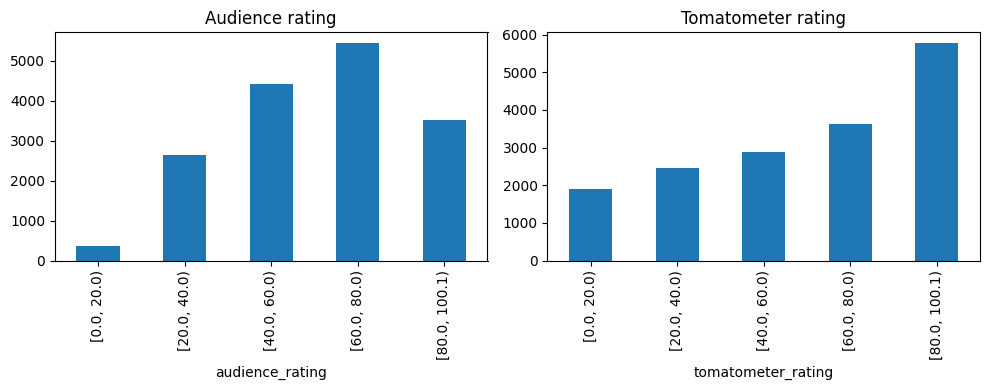

Correlación entre duración y valoración del público: 0.1685205013570624
Correlación duración ↔ audiencia_rating: 0.1685205013570624
Correlación duración ↔ audience_count: 0.04879529592590476
Correlación duración ↔ tomatometer_rating: 0.07128792344373774
Matriz de correlaciones:


,runtime_in_minutes,tomatometer_rating,tomatometer_count,audience_rating,audience_count
runtime_in_minutes,1.000000,0.071288,0.191899,0.168521,0.048795
tomatometer_rating,0.071288,1.000000,0.079529,0.660114,0.014425
tomatometer_count,0.191899,0.079529,1.000000,0.140975,0.132684
audience_rating,0.168521,0.660114,0.140975,1.000000,0.022810
audience_count,0.048795,0.014425,0.132684,0.022810,1.000000


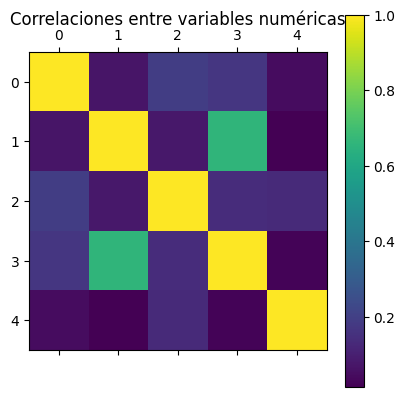

In [27]:
#tutorial de youtube que he seguido https://www.youtube.com/watch?v=r1ZVISvsaqU
 
#Miro los maxioss
maximos = {
    'runtime_in_minutes': df['runtime_in_minutes'].max(),
    'tomatometer_rating': df['tomatometer_rating'].max(),
    'audience_rating': df['audience_rating'].max(),
    'tomatometer_count': df['tomatometer_count'].max(),
    'audience_count': df['audience_count'].max()
}
display(maximos)
#Miro los minimos
minimos = {
    'runtime_in_minutes': df['runtime_in_minutes'].min(),
    'tomatometer_rating': df['tomatometer_rating'].min(),
    'audience_rating': df['audience_rating'].min(),
    'tomatometer_count': df['tomatometer_count'].min(),
    'audience_count': df['audience_count'].min()
}
display(minimos)
 
#de momento pongo que haya 5 intervalos
intervalos = 5
 
#calcula los intervalos de cada atributo
anchos_intervalos = {
    key: (maximos[key] - minimos[key]) / intervalos
    for key in maximos.keys()
}
anchos_intervalos
 
#Hago la tabla de pfrequencias de audience_rating
tabla_frecuencias_audience = pd.cut(df['audience_rating'],
                          bins=intervalos,
                          right=False).value_counts().sort_index()
display(tabla_frecuencias_audience.to_frame(name='Frecuencia'))
 

#Hago la tabla de pfrequencias de audience_rating
tabla_frecuencias_tomatometer = pd.cut(df['tomatometer_rating'],
                          bins=intervalos,
                          right=False).value_counts().sort_index()
display(tabla_frecuencias_tomatometer.to_frame(name='Frecuencia'))


fig, axes = plt.subplots(1, 2, figsize=(10,4))
 
tabla_frecuencias_audience.plot(kind='bar', ax=axes[0], title='Audience rating')
tabla_frecuencias_tomatometer.plot(kind='bar', ax=axes[1], title='Tomatometer rating')
 
plt.tight_layout()
plt.show()

correlacion = df['runtime_in_minutes'].corr(df['audience_rating'])
print("Correlación entre duración y valoración del público:", correlacion)
df[['runtime_in_minutes', 'audience_rating']].corr()

corr_runtime_audience = df['runtime_in_minutes'].corr(df['audience_rating'])
print("Correlación duración ↔ audiencia_rating:", corr_runtime_audience)

corr_runtime_audience_count = df['runtime_in_minutes'].corr(df['audience_count'])
print("Correlación duración ↔ audience_count:", corr_runtime_audience_count)

corr_runtime_tomatometer = df['runtime_in_minutes'].corr(df['tomatometer_rating'])
print("Correlación duración ↔ tomatometer_rating:", corr_runtime_tomatometer)

cols = [
    'runtime_in_minutes',
    'tomatometer_rating',
    'tomatometer_count',
    'audience_rating',
    'audience_count'
]

correlation_matrix = df[cols].corr()

print("Matriz de correlaciones:")
display(correlation_matrix)

plt.matshow(correlation_matrix)
plt.colorbar()
plt.title("Correlaciones entre variables numéricas", pad=20)
plt.show()



## 3.1 Estadisticas globales

## 3.2 Análisis por género

## 3.3 Análisis por estudio o director

## 3.4 Analisis temporal

## 3.5 Análisis de retraso a streaming (si aplica)

## 4. Uso de NumPy para análisis auxiliar

## 5. Preguntes

## 6. Conclusiones

In [ ]:
# Conteo de valores nulos por columna
print("Valores nulos por columna:")
print(df.isna().sum())

# Rellenar NaN en columnas numéricas clave con valores por defecto
df.fillna({'screen_time(min)': 0, 'notifications': 0}, inplace=True)

# Eliminar filas que no tengan app o tiempo de pantalla (esenciales para análisis)
df.dropna(subset=['critics_consensus'], inplace=True)

print('\nDespués de limpieza de NaN:')
print(df.isna().sum())

display(df.head())


## 5. Eliminación de columnas vacías

In [ ]:
# Eliminamos columnas que estén completamente vacías
print("Columnas actuales del DataFrame:")
print(df.columns.tolist())
df.dropna(axis=1, how='all', inplace=True)

print("Columnas actuales del DataFrame:")
print(df.columns.tolist())


Columnas actuales del DataFrame:
['movie_title', 'movie_info', 'critics_consensus', 'rating', 'genre', 'directors', 'writers', 'cast', 'in_theaters_date', 'on_streaming_date', 'runtime_in_minutes', 'studio_name', 'tomatometer_status', 'tomatometer_rating', 'tomatometer_count', 'audience_rating', 'audience_count', 'columna_vacia']
Columnas actuales del DataFrame:
['movie_title', 'movie_info', 'critics_consensus', 'rating', 'genre', 'directors', 'writers', 'cast', 'in_theaters_date', 'on_streaming_date', 'runtime_in_minutes', 'studio_name', 'tomatometer_status', 'tomatometer_rating', 'tomatometer_count', 'audience_rating', 'audience_count']


## 6. Limpieza y normalización de texto (`.str` en Pandas)

In [ ]:
# Normalizar nombres de apps:
# - quitar espacios en blanco
# - poner la primera letra en mayúscula de cada palabra
# - eliminar espacios internos (Instagram  -> Instagram, 'YouTube Music' -> 'Youtubemusic')
df['app_name'] = (
    df['app_name']
      .astype(str)
      .str.strip()
      .str.title()
      .str.replace(' ', '', regex=False)
)
 
display(df[['app_name']].head(10))
 
# Buscar todas las filas que contienen "Youtube"
youtube_rows = df[df['app_name'].str.contains('Youtube', case=False, na=False)]
print("Filas con Youtube:")
display(youtube_rows)

## 7. Métodos extra de cadena (`str.len`, `str.startswith`, etc.)

In [ ]:
# Longitud del nombre de la app
df['app_name_len'] = df['app_name'].str.len()

# Apps que empiezan por 'Y'
apps_y = df[df['app_name'].str.startswith('Y', na=False)]

print("Apps que empiezan por 'Y':")
display(apps_y[['app_name', 'app_name_len']].drop_duplicates())

display(df[['app_name', 'app_name_len']].head())


## 8. Detección de tipos mezclados en columnas

In [ ]:
print("Tipos actuales:")
print(df.dtypes)

print("\nTipo real de cada celda en las primeras filas:")
display(df.applymap(type).head())

# Convertir automáticamente al tipo más adecuado (opcional)
df = df.convert_dtypes()

print("\nTipos tras convert_dtypes():")
print(df.dtypes)


## 9. Guardar el dataset limpio

In [ ]:
df.to_csv('screentime_analysis_clean.csv', index=False)
print('Archivo screentime_analysis_clean.csv guardado correctamente.')

Archivo screentime_analysis_clean.csv guardado correctamente.


## 10. Mini análisis final por aplicación

In [ ]:
# ¿Qué apps tienen más tiempo medio de pantalla?
screen_time_media = (
    df.groupby('app_name')['screen_time(min)']
      .mean()
      .sort_values(ascending=False)
)

print("Tiempo medio de pantalla (min) por app:")
display(screen_time_media)

# ¿Qué apps generan más notificaciones?
notif_media = (
    df.groupby('app_name')['notifications']
      .mean()
      .sort_values(ascending=False)
)

print("Notificaciones medias por app:")
display(notif_media)
